# Analise dos dados

## Envs

In [9]:
DATASET_ORIGIN = "KAGGLE"
DATASET_NAME = "IMDB Movie Reviews"
DATASET_KAGGLE_ID = "yeanzc/telco-customer-churn-ibm-dataset"
DATASET_DESTINATION = "data/imdb_movie_reviews"
DATASET_FILE = "Telco_customer_churn.xlsx"


## Libs

In [19]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Download dos dados

In [6]:
kagglehub.dataset_download(DATASET_KAGGLE_ID, output_dir=DATASET_DESTINATION)

100%|██████████| 1.25M/1.25M [00:00<00:00, 3.30MB/s]

Extracting files...


'data/imdb_movie_reviews'

## Carregando os dados

In [11]:
dataset_raw = pd.read_excel(f"{DATASET_DESTINATION}/{DATASET_FILE}")

## Info dos dados

In [13]:
dataset_raw.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [14]:
dataset_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

Resumo do que foi encontrado:
- Volume: 7043 instancias e 33 colunas
- Qualidade: Apenas a ultima coluna `Churn Reason` tem dados nulos
> insight: Esperado pois apenas quem deu chrun tem motivo para colocar o reason
- Tipos de dados: float64(3), int64(6), object(1), str(23)
> insight: O objeto e as strings precisaram de enconding 


In [15]:
dataset_raw.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [16]:
dataset_raw.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Confirmado que apenas a coluna `Churn Reason` possui valores nulos, em um total de 5174 instancias

In [18]:
dataset_raw.duplicated().sum()

np.int64(0)

Nenhum dado duplicado foi encontrado

### Distribuição da variavel algo

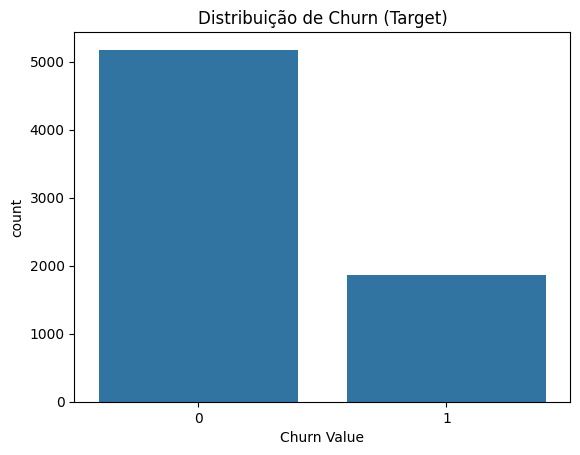

In [22]:
sns.countplot(x="Churn Value", data=dataset_raw)
plt.title("Distribuição de Churn (Target)")
plt.show()

A base se demonstra desbalanceada, o que indica que não é interessante utilizar Acurácia como métrica principal

### Tempo de contrato

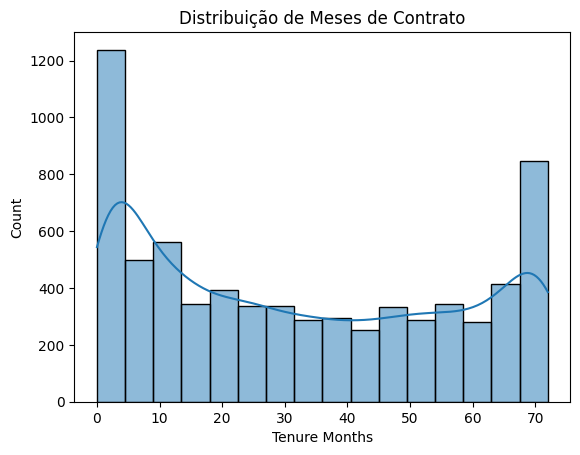

In [ ]:
sns.histplot(dataset_raw["Tenure Months"], kde=True)
plt.title("Distribuição de Meses de Contrato")
plt.show()

sns.boxplot(x="Churn Value", y="Tenure Months", data=dataset_raw)
plt.title("Ganhos Mensais vs Churn")
plt.show()


In [ ]:
sns.boxplot(x="Churn Value", y="Monthly Charges", data=dataset_raw)
plt.title("Ganhos Mensais vs Churn")
plt.show()

- A mediana de gasto quem cancela é de cerca 80 unidades, enquanto de quem fica cerca de 65.
- Não existem outliers relevantes no gasto